# Project Overview

## Business Problem
A subscription-based telecom provider is experiencing customer churn, impacting recurring revenue and customer lifetime value.

The company aims to identify customers at high risk of canceling so that targeted retention efforts can be deployed proactively.

## Project Objective
Build and evaluate a classification model that predicts customer churn using demographic, contract, and service usage data.

In addition to predictive performance, identify key churn drivers and translate insights into actionable retention strategies.

## Key Stakeholder Question
Which customers are most likely to churn, and how should retention efforts be prioritized to reduce missed churners and unnecessary outreach?

## Project Workflow
1. Data understanding and preparation  
2. Exploratory data analysis (EDA)  
3. Feature engineering  
4. Model development and evaluation  
5. Business insights and recommendations    

# 1. Data Understanding and Preparation

In [ ]:
# ==================================================
# Load Data and Initial Inspection
# ==================================================

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

# Load raw dataset
raw_churn_df = pd.read_csv("telecom_customer_churn.csv")
churn_df = raw_churn_df.copy()

# Basic structure overview
display(churn_df.head())
churn_df.info()

# Dataset shape
print("Dataset shape:", churn_df.shape)

# Missing values (show only columns with missing data)
missing = churn_df.isna().sum().sort_values(ascending=False)
display(missing[missing > 0])

# Summary statistics
display(churn_df.describe())

# Target distribution
display(
    churn_df["Customer Status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(1)
)

,Customer ID,Gender,Age,Married,Number of Dependents,City,Zip Code,Latitude,Longitude,Number of Referrals,...,Payment Method,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue,Customer Status,Churn Category,Churn Reason
0,0002-ORFBO,Female,37,Yes,0,Frazier Park,93225,34.827662,-118.999073,2,...,Credit Card,65.6,593.30,0.00,0,381.51,974.81,Stayed,NaN,NaN
1,0003-MKNFE,Male,46,No,0,Glendale,91206,34.162515,-118.203869,0,...,Credit Card,-4.0,542.40,38.33,10,96.21,610.28,Stayed,NaN,NaN
2,0004-TLHLJ,Male,50,No,0,Costa Mesa,92627,33.645672,-117.922613,0,...,Bank Withdrawal,73.9,280.85,0.00,0,134.60,415.45,Churned,Competitor,Competitor had better devices
3,0011-IGKFF,Male,78,Yes,0,Martinez,94553,38.014457,-122.115432,1,...,Bank Withdrawal,98.0,1237.85,0.00,0,361.66,1599.51,Churned,Dissatisfaction,Product dissatisfaction
4,0013-EXCHZ,Female,75,Yes,0,Camarillo,93010,34.227846,-119.079903,3,...,Credit Card,83.9,267.40,0.00,0,22.14,289.54,Churned,Dissatisfaction,Network reliability


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 38 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Customer ID                        7043 non-null   object 
 1   Gender                             7043 non-null   object 
 2   Age                                7043 non-null   int64  
 3   Married                            7043 non-null   object 
 4   Number of Dependents               7043 non-null   int64  
 5   City                               7043 non-null   object 
 6   Zip Code                           7043 non-null   int64  
 7   Latitude                           7043 non-null   float64
 8   Longitude                          7043 non-null   float64
 9   Number of Referrals                7043 non-null   int64  
 10  Tenure in Months                   7043 non-null   int64  
 11  Offer                              3166 non-null   objec

,0
Churn Reason,5174
Churn Category,5174
Offer,3877
Online Backup,1526
Avg Monthly GB Download,1526
Online Security,1526
Streaming Movies,1526
Streaming TV,1526
Unlimited Data,1526
Streaming Music,1526


,Age,Number of Dependents,Zip Code,Latitude,Longitude,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Charges,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,Total Revenue
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,6361.000000,5517.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,46.509726,0.468692,93486.070567,36.197455,-119.756684,1.951867,32.386767,25.420517,26.189958,63.596131,2280.381264,1.962182,6.860713,749.099262,3034.379056
std,16.750352,0.962802,1856.767505,2.468929,2.154425,3.001199,24.542061,14.200374,19.586585,31.204743,2266.220462,7.902614,25.104978,846.660055,2865.204542
min,19.000000,0.000000,90001.000000,32.555828,-124.301372,0.000000,1.000000,1.010000,2.000000,-10.000000,18.800000,0.000000,0.000000,0.000000,21.360000
25%,32.000000,0.000000,92101.000000,33.990646,-121.788090,0.000000,9.000000,13.050000,13.000000,30.400000,400.150000,0.000000,0.000000,70.545000,605.610000
50%,46.000000,0.000000,93518.000000,36.205465,-119.595293,0.000000,29.000000,25.690000,21.000000,70.050000,1394.550000,0.000000,0.000000,401.440000,2108.640000
75%,60.000000,0.000000,95329.000000,38.161321,-117.969795,3.000000,55.000000,37.680000,30.000000,89.750000,3786.600000,0.000000,0.000000,1191.100000,4801.145000
max,80.000000,9.000000,96150.000000,41.962127,-114.192901,11.000000,72.000000,49.990000,85.000000,118.750000,8684.800000,49.790000,150.000000,3564.720000,11979.340000


,proportion
Customer Status,
Stayed,67.0
Churned,26.5
Joined,6.4


### Initial Observations

- The dataset contains 7,043 rows and 38 columns, providing sufficient data for model training and evaluation.

- Each row represents a unique customer at the end of fiscal Q2 2022. All features reflect customer attributes at that point in time.

- The dataset includes numeric and categorical variables that will require encoding prior to modeling.

- Missing values are concentrated in service-related features and appear to reflect customers without those services rather than data errors.

- Approximately 27% of customers churned, indicating moderate class imbalance. Model evaluation will prioritize recall, precision, and ROC-AUC, and class weighting may be considered.

In [ ]:
# ==================================================
# Define the Modeling Dataset (Target + Drops)
# ==================================================

# Keep only customers who were already with the company (exclude brand-new "Joined" customers)
churn_df = churn_df[churn_df["Customer Status"] != "Joined"].copy()

# Create the target we want to predict:
# Churn = 1 means the customer churned
# Churn = 0 means the customer stayed
churn_df["Churn"] = churn_df["Customer Status"].map({
    "Stayed": 0,
    "Churned": 1
})

# Quick safety check: if this fails, there are unexpected labels in "Customer Status"
assert churn_df["Churn"].notna().all(), "Unmapped values found in Customer Status"

# Columns we remove before modeling (grouped by why we’re removing them)
drop_groups = {
    # Not useful for prediction (just a unique label for each customer)
    "identifiers": ["Customer ID"],

    # These reveal the churn outcome after the fact (would “cheat” the model)
    "leakage": ["Customer Status", "Churn Category", "Churn Reason"],

    # Location fields (excluded here to keep the model simpler and easier to explain)
    "geography": ["City", "Zip Code", "Latitude", "Longitude"],

    # Very strong financial summary feature (we’ll test later if needed)
    "high_correlation": ["Total Revenue"]
}

# Combine all the groups into one drop list
cols_to_drop = [col for group in drop_groups.values() for col in group]

# Drop only columns that actually exist in the dataset (prevents errors if names differ)
cols_to_drop = [col for col in cols_to_drop if col in churn_df.columns]

# Create the modeling dataset (separate from cleaned base dataset)
model_df = churn_df.drop(columns=cols_to_drop).copy()

print("Base dataset shape (after filtering):", churn_df.shape)
print("Modeling dataset shape:", model_df.shape)


Base dataset shape (after filtering): (6589, 39)
Modeling dataset shape: (6589, 30)


### Modeling Population Definition

- Excluded newly joined customers to focus on existing customers at risk of churn.
- Created a binary target variable `Churn` (1 = churned, 0 = stayed).
- Removed identifier and leakage-related columns prior to modeling.

In [ ]:
# ==================================================
# Missing Value Validation
# ==================================================

# Internet-related features:
# Check whether missing values occur only for customers
# who do not have internet service.

internet_categorical = [
    "Internet Type",
    "Online Security",
    "Online Backup",
    "Device Protection Plan",
    "Premium Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Streaming Music",
    "Unlimited Data"
]

internet_numeric = [
    "Avg Monthly GB Download"
]

for col in internet_categorical + internet_numeric:
    missing_internet_type = model_df.loc[
        model_df[col].isna(),
        "Internet Type"
    ].value_counts(dropna=False)

    print(f"\nMissing values in '{col}' occur with Internet Type:")
    print(missing_internet_type)


# Phone-related features:
# Check whether missing values occur only for customers
# who do not have phone service.

phone_related_cols = [
    "Avg Monthly Long Distance Charges",
    "Multiple Lines"
]

for col in phone_related_cols:
    print(f"\nMissing values in '{col}' occur with Phone Service:")
    display(
        model_df.loc[
            model_df[col].isna(),
            "Phone Service"
        ].value_counts(dropna=False)
    )


# Promotional information:
# Confirm whether missing values exist
# or if no promotion is already recorded as "None".

promo_cols = [
    "Offer"
]

display(model_df["Offer"].value_counts(dropna=False))


Missing values in 'Internet Type' occur with Internet Type:
Internet Type
NaN    1344
Name: count, dtype: int64

Missing values in 'Online Security' occur with Internet Type:
Internet Type
NaN    1344
Name: count, dtype: int64

Missing values in 'Online Backup' occur with Internet Type:
Internet Type
NaN    1344
Name: count, dtype: int64

Missing values in 'Device Protection Plan' occur with Internet Type:
Internet Type
NaN    1344
Name: count, dtype: int64

Missing values in 'Premium Tech Support' occur with Internet Type:
Internet Type
NaN    1344
Name: count, dtype: int64

Missing values in 'Streaming TV' occur with Internet Type:
Internet Type
NaN    1344
Name: count, dtype: int64

Missing values in 'Streaming Movies' occur with Internet Type:
Internet Type
NaN    1344
Name: count, dtype: int64

Missing values in 'Streaming Music' occur with Internet Type:
Internet Type
NaN    1344
Name: count, dtype: int64

Missing values in 'Unlimited Data' occur with Internet Type:
Internet Typ

,count
Phone Service,
No,644



Missing values in 'Multiple Lines' occur with Phone Service:


,count
Phone Service,
No,644


,count
Offer,
NaN,3598
Offer B,824
Offer E,630
Offer D,602
Offer A,520
Offer C,415


In [ ]:
# ==================================================
# Handle Missing Values (based on validation results)
# ==================================================

# Internet-related features:
# Missing = customer does not have internet service
model_df[internet_categorical] = model_df[internet_categorical].fillna("No Internet")
model_df[internet_numeric] = model_df[internet_numeric].fillna(0)

# Phone-related features:
# Missing = customer does not have phone service
model_df["Avg Monthly Long Distance Charges"] = model_df["Avg Monthly Long Distance Charges"].fillna(0)
model_df["Multiple Lines"] = model_df["Multiple Lines"].fillna("No")

# Offer:
# If "None" is already used to represent no active offer, only fill if NaNs exist
if model_df["Offer"].isna().sum() > 0:
    model_df["Offer"] = model_df["Offer"].fillna("None")

# Final validation
print("Missing values remaining:", model_df.isna().sum().sum())
display(model_df.isna().sum().sort_values(ascending=False).head(10))
model_df.info()

Missing values remaining: 0


,0
Gender,0
Age,0
Married,0
Number of Dependents,0
Number of Referrals,0
Tenure in Months,0
Offer,0
Phone Service,0
Avg Monthly Long Distance Charges,0
Multiple Lines,0


<class 'pandas.core.frame.DataFrame'>
Index: 6589 entries, 0 to 7042
Data columns (total 30 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Gender                             6589 non-null   object 
 1   Age                                6589 non-null   int64  
 2   Married                            6589 non-null   object 
 3   Number of Dependents               6589 non-null   int64  
 4   Number of Referrals                6589 non-null   int64  
 5   Tenure in Months                   6589 non-null   int64  
 6   Offer                              6589 non-null   object 
 7   Phone Service                      6589 non-null   object 
 8   Avg Monthly Long Distance Charges  6589 non-null   float64
 9   Multiple Lines                     6589 non-null   object 
 10  Internet Service                   6589 non-null   object 
 11  Internet Type                      6589 non-null   object 
 1

In [ ]:
# ==================================================
# Duplicate Check
# ==================================================

print("Full row duplicates:", model_df.duplicated().sum())
print("Duplicate Customer IDs:", raw_churn_df["Customer ID"].duplicated().sum())

Full row duplicates: 0
Duplicate Customer IDs: 0


### Data Preparation Summary

Missing values were handled based on business meaning rather than treated as data errors.

- **Internet features:** Missing values occur only when a customer does not have internet service.  
  - Internet-related categories → `"No Internet"`  
  - Internet usage → `0`

- **Phone features:** Missing values occur only when a customer does not have phone service.  
  - Long distance charges → `0`  
  - Multiple lines → `"No"`

- **Offer:** The dataset uses `"None"` to represent no active promotion.  
  - Missing values were filled with `"None"` only if present.

No duplicate customer records were identified.

The dataset is now clean and model-ready.

# 2. Exploratory Data Analysis (EDA)

This section explores patterns in customer behavior to better understand the drivers of churn.

In [ ]:
# Set consistent plot style for EDA
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7,4)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 11

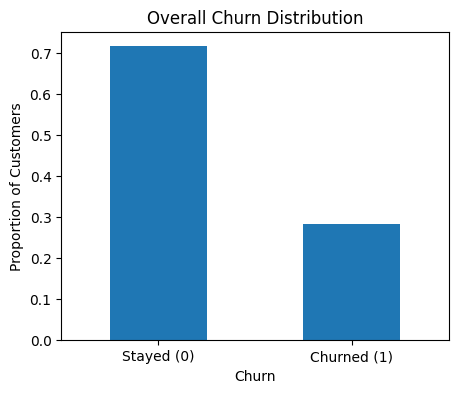

Churn rate: 28.4 %


In [ ]:
# Churn distribution
churn_rate = model_df["Churn"].value_counts(normalize=True)

ax = churn_rate.sort_index().plot(kind="bar", figsize=(5,4))
ax.set_xticklabels(["Stayed (0)", "Churned (1)"], rotation=0)
ax.set_ylabel("Proportion of Customers")
ax.set_title("Overall Churn Distribution")
plt.show()

print("Churn rate:", round(churn_rate[1] * 100, 1), "%")

Approximately 27% of customers churned. While not extreme, this class imbalance will influence model evaluation and threshold selection.

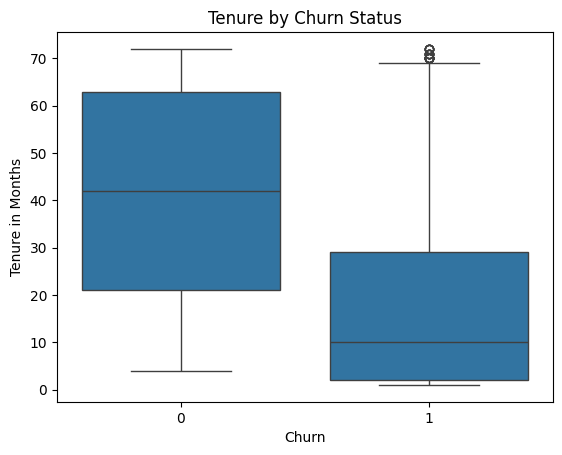

In [ ]:
sns.boxplot(x="Churn", y="Tenure in Months", data=model_df)
plt.title("Tenure by Churn Status")
plt.show()

Customers who churn tend to have significantly shorter tenure, suggesting early-stage retention is critical.

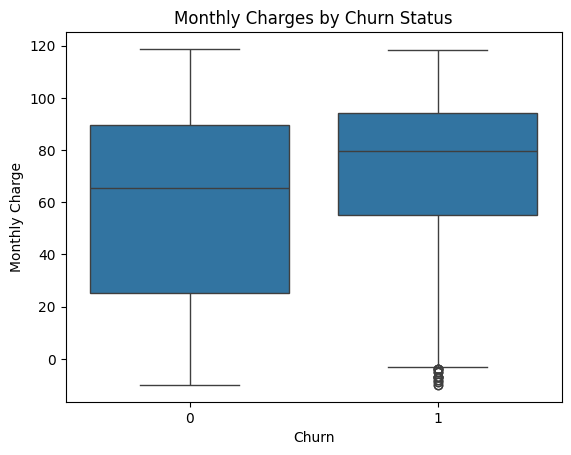

In [ ]:
sns.boxplot(x="Churn", y="Monthly Charge", data=model_df)
plt.title("Monthly Charges by Churn Status")
plt.show()

Customers with higher monthly charges appear more likely to churn, indicating price sensitivity may influence retention.

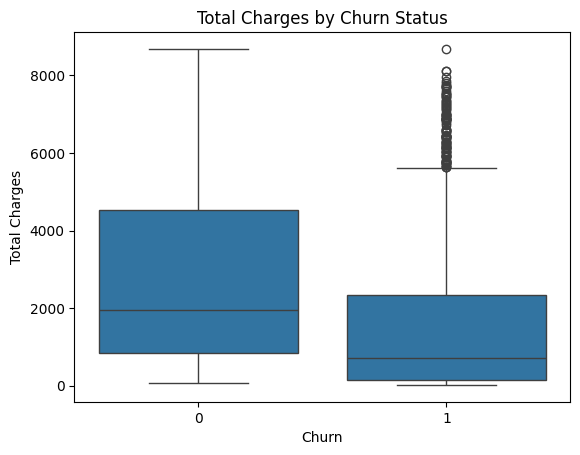

In [ ]:
sns.boxplot(x="Churn", y="Total Charges", data=model_df)
plt.title("Total Charges by Churn Status")
plt.show()

Customers who churn have significantly lower total accumulated charges compared to retained customers.

This pattern is largely driven by tenure, as customers who leave earlier have had less time to accumulate charges.

Total Charges appears strongly correlated with tenure and may not provide independent predictive value beyond customer longevity.

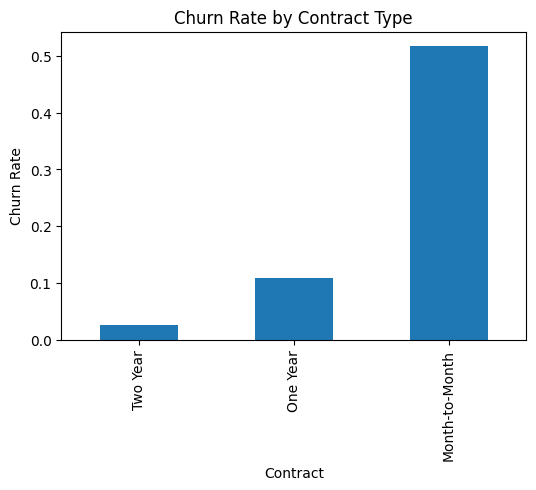

In [ ]:
contract_churn = model_df.groupby("Contract")["Churn"].mean().sort_values()

contract_churn.plot(kind="bar", figsize=(6,4))
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Contract Type")
plt.show()

Month-to-month contracts show significantly higher churn compared to longer-term contracts, indicating contract commitment plays a key role.

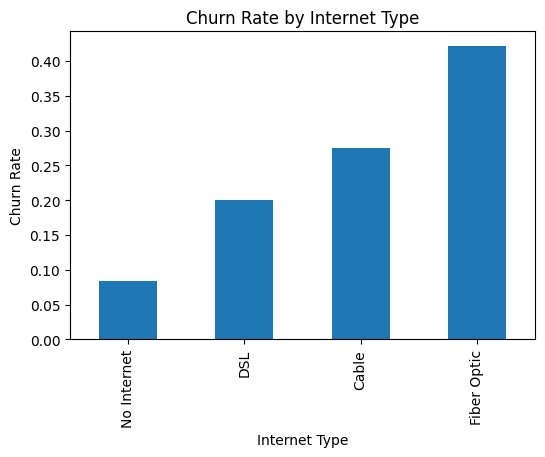

In [ ]:
internet_churn = model_df.groupby("Internet Type")["Churn"].mean().sort_values()

internet_churn.plot(kind="bar", figsize=(6,4))
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Internet Type")
plt.show()

Churn rates vary significantly by internet type. Fiber Optic customers exhibit the highest churn rate (approximately 42%), followed by Cable (around 28%) and DSL (around 20%), while customers without internet service have the lowest churn (about 9%).

This pattern suggests that internet type — particularly Fiber — may be a strong driver of churn. The elevated churn among Fiber customers may reflect higher pricing, stronger competition, or elevated service expectations.

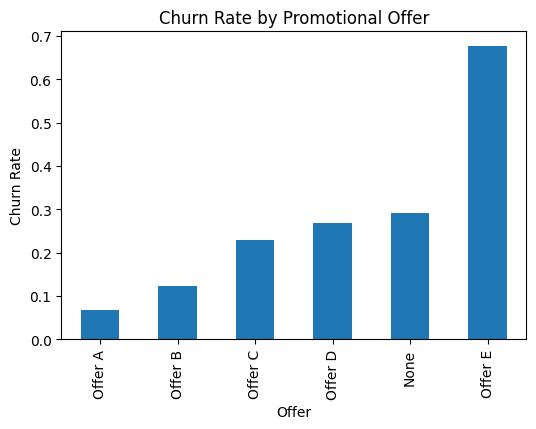

In [ ]:
offer_churn = model_df.groupby("Offer")["Churn"].mean().sort_values()

offer_churn.plot(kind="bar", figsize=(6,4))
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Promotional Offer")
plt.show()

Churn rates vary substantially across promotional offers. Customers receiving Offer A and Offer B exhibit the lowest churn rates, suggesting these promotions may be effective retention tools.

Customers without any active offer ("None") show a noticeably higher churn rate, reinforcing the potential value of targeted incentives.

Notably, Offer E is associated with the highest churn rate (approximately 68%), which may indicate that this promotion targets high-risk customers or is offered reactively to customers already likely to churn.

These findings suggest that promotional strategy plays a meaningful role in customer retention, though further analysis is needed to determine whether offers reduce churn or are assigned based on churn risk.

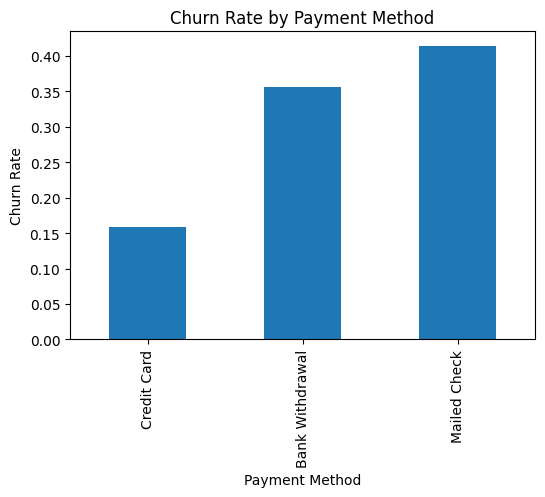

In [ ]:
payment_churn = model_df.groupby("Payment Method")["Churn"].mean().sort_values()

payment_churn.plot(kind="bar", figsize=(6,4))
plt.ylabel("Churn Rate")
plt.title("Churn Rate by Payment Method")
plt.show()

Churn rates differ meaningfully by payment method. Customers paying by Credit Card exhibit the lowest churn rate (approximately 16%), while customers using Bank Withdrawal show substantially higher churn (around 36%).

Customers paying by Mailed Check have the highest churn rate (approximately 41%), more than double that of credit card users.

This pattern suggests that automatic or digital payment methods may be associated with stronger customer retention, while manual payment methods may reflect lower engagement, higher friction, or greater likelihood of switching providers.

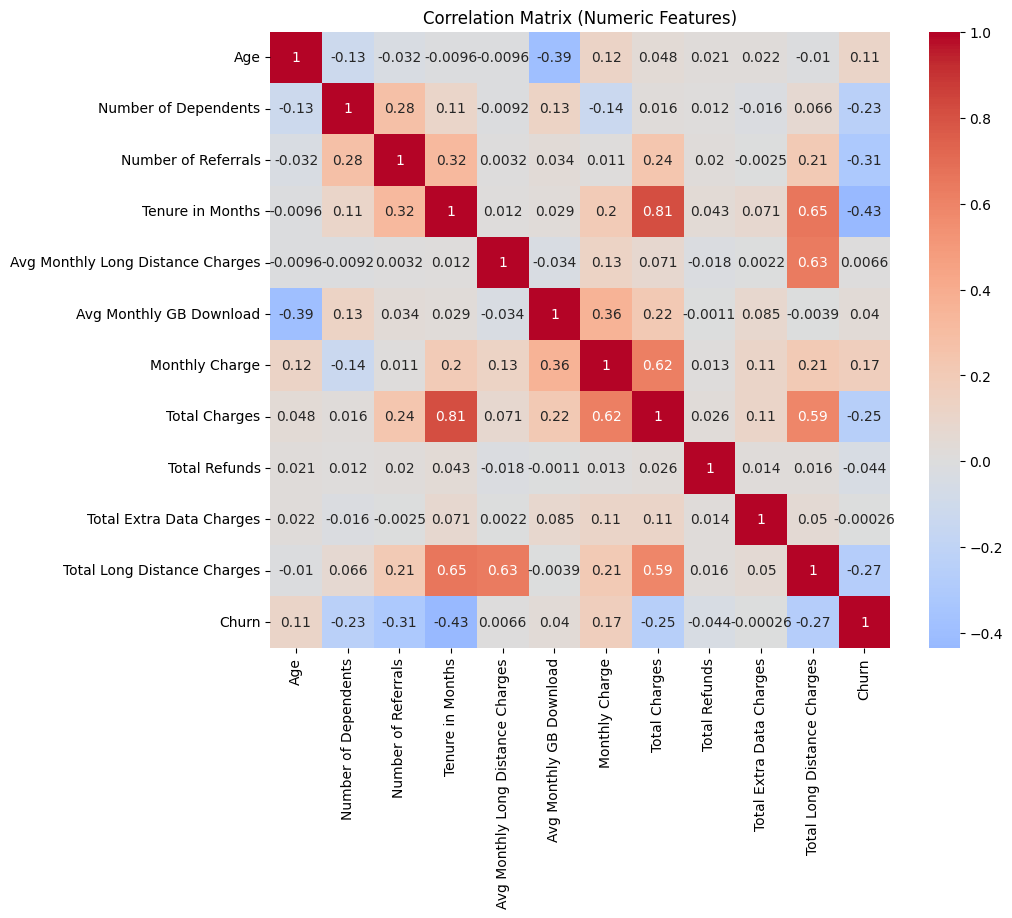

In [ ]:
numeric_cols = model_df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(10,8))
sns.heatmap(
    model_df[numeric_cols].corr(),
    cmap="coolwarm",
    center=0,
    annot=True,
)
plt.title("Correlation Matrix (Numeric Features)")
plt.show()

### Correlation Analysis (Numeric Features)

Among numeric variables, Tenure in Months shows the strongest relationship with churn (correlation ≈ -0.43), indicating that longer-tenured customers are significantly less likely to churn.

Number of Referrals (-0.31) and Total Charges (-0.25) also show meaningful negative relationships with churn, suggesting that customer engagement and longevity reduce churn risk.

Monthly Charge exhibits a positive correlation with churn (≈ 0.17), indicating that higher pricing may contribute to increased churn probability.

Tenure and Total Charges are highly correlated (≈ 0.81), which is expected given that total charges accumulate over time. This multicollinearity will be considered during feature selection.

---



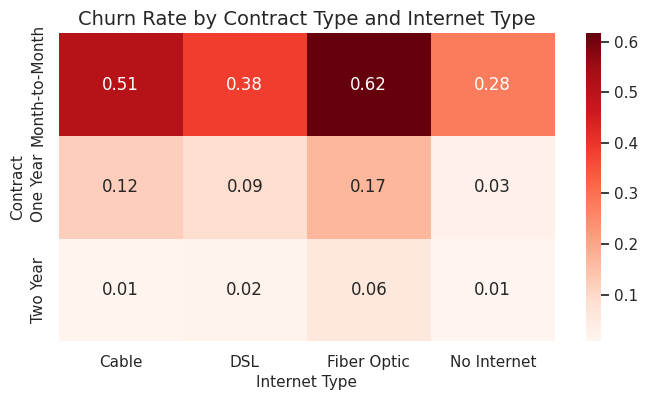

In [ ]:
# ==================================================
# Interaction: Contract Type × Internet Type
# ==================================================

interaction = model_df.pivot_table(
    values="Churn",
    index="Contract",
    columns="Internet Type",
    aggfunc="mean"
)

plt.figure(figsize=(8,4))
sns.heatmap(interaction, annot=True, fmt=".2f", cmap="Reds")
plt.title("Churn Rate by Contract Type and Internet Type")
plt.ylabel("Contract")
plt.xlabel("Internet Type")
plt.show()

### Interaction Insight: Contract and Internet Type

Churn risk is highest among customers on month-to-month contracts who also subscribe to Fiber internet.

This suggests that short-term commitment combined with higher-priced or higher-expectation services creates elevated churn risk.

Customers with long-term contracts exhibit substantially lower churn across all internet types.

In [ ]:
# ==================================================
# Top High-Risk Customer Segments
# ==================================================

segment_cols = ["Contract", "Internet Type", "Payment Method"]

segment_summary = (
    model_df.groupby(segment_cols)["Churn"]
    .agg(churn_rate="mean", customers="size")
    .reset_index()
)

# Filter out very small segments
segment_summary = segment_summary[segment_summary["customers"] >= 100]

segment_summary = segment_summary.sort_values("churn_rate", ascending=False)

segment_summary["churn_rate"] = (segment_summary["churn_rate"] * 100).round(1)

display(segment_summary.head(10))

,Contract,Internet Type,Payment Method,churn_rate,customers
6,Month-to-Month,Fiber Optic,Bank Withdrawal,64.7,1373
0,Month-to-Month,Cable,Bank Withdrawal,54.6,218
7,Month-to-Month,Fiber Optic,Credit Card,47.6,368
3,Month-to-Month,DSL,Bank Withdrawal,41.6,389
1,Month-to-Month,Cable,Credit Card,37.4,107
4,Month-to-Month,DSL,Credit Card,28.8,243
10,Month-to-Month,No Internet,Credit Card,21.7,207
18,One Year,Fiber Optic,Bank Withdrawal,17.9,386
19,One Year,Fiber Optic,Credit Card,13.6,184
15,One Year,DSL,Bank Withdrawal,8.2,194


### Highest-Risk Customer Segments

The highest churn segments are consistently characterized by month-to-month contracts, particularly when combined with Fiber internet service.

The single highest-risk group consists of customers on month-to-month contracts with Fiber internet paying via bank withdrawal (64.7% churn, 1,373 customers).

While payment method influences churn rates, contract type appears to be the dominant risk driver, with internet type further amplifying churn probability.

These segments represent priority candidates for proactive retention outreach.

# 3. Feature Engineering

This section prepares the dataset for modeling by encoding categorical variables, addressing multicollinearity, and ensuring features are appropriately structured for classification.

In [ ]:
# ==================================================
# Remove Redundant Features
# ==================================================

# Drop Total Charges due to high correlation with Tenure
if "Total Charges" in model_df.columns:
    model_df = model_df.drop(columns=["Total Charges"])

print("Updated feature set shape:", model_df.shape)

Updated feature set shape: (6589, 29)


### Multicollinearity Handling

Total Charges was removed due to strong correlation with Tenure in Months (≈ 0.81).

Since total charges accumulate over time, Tenure captures similar lifecycle information while remaining more interpretable.

In [ ]:
# ==================================================
# One-Hot Encode Categorical Variables
# ==================================================

categorical_cols = model_df.select_dtypes(include="object").columns

model_encoded = pd.get_dummies(
    model_df,
    columns=categorical_cols,
    drop_first=True
)

print("Encoded dataset shape:", model_encoded.shape)

Encoded dataset shape: (6589, 45)


### Categorical Encoding

Categorical variables were one-hot encoded to allow use in logistic regression and tree-based models.

The first level of each category was dropped to avoid multicollinearity.

In [ ]:
model_encoded

,Age,Number of Dependents,Number of Referrals,Tenure in Months,Avg Monthly Long Distance Charges,Avg Monthly GB Download,Monthly Charge,Total Refunds,Total Extra Data Charges,Total Long Distance Charges,...,Streaming Movies_Yes,Streaming Music_No Internet,Streaming Music_Yes,Unlimited Data_No Internet,Unlimited Data_Yes,Contract_One Year,Contract_Two Year,Paperless Billing_Yes,Payment Method_Credit Card,Payment Method_Mailed Check
0,37,0,2,9,42.39,16.0,65.60,0.00,0,381.51,...,False,False,False,False,True,True,False,True,True,False
1,46,0,0,9,10.69,10.0,-4.00,38.33,10,96.21,...,True,False,True,False,False,False,False,False,True,False
2,50,0,0,4,33.65,30.0,73.90,0.00,0,134.60,...,False,False,False,False,True,False,False,True,False,False
3,78,0,1,13,27.82,4.0,98.00,0.00,0,361.66,...,True,False,False,False,True,False,False,True,False,False
4,75,0,3,3,7.38,11.0,83.90,0.00,0,22.14,...,False,False,False,False,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7037,36,0,0,4,2.01,0.0,20.95,0.00,0,8.04,...,False,True,False,True,False,False,False,False,False,False
7038,20,0,0,13,46.68,59.0,55.15,0.00,0,606.84,...,False,False,True,False,True,True,False,False,True,False
7039,40,0,1,22,16.20,17.0,85.10,0.00,0,356.40,...,True,False,True,False,True,False,False,True,False,False
7041,21,0,5,67,2.12,58.0,67.85,0.00,0,142.04,...,True,False,True,False,True,False,True,False,True,False


In [ ]:
# ==================================================
# Define Features (X) and Target (y)
# ==================================================

X = model_encoded.drop(columns=["Churn"])
y = model_encoded["Churn"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (6589, 44)
Target shape: (6589,)


In [ ]:
from sklearn.model_selection import train_test_split

# Stratify to preserve churn distribution
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Test set size:", X_test.shape)

Training set size: (5271, 44)
Test set size: (1318, 44)


### Train-Test Split

Data was split using stratified sampling to preserve churn distribution across training and test sets.

This ensures fair model evaluation.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

numeric_cols = X_train.select_dtypes(include=["int64", "float64"]).columns

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

print("Scaling complete.")

Scaling complete.


### Feature Scaling

Numeric features were standardized to support models sensitive to feature magnitude (e.g., logistic regression).

Tree-based models will use the unscaled feature set.

## Feature Engineering Summary

- Removed highly correlated features to reduce redundancy.
- Applied one-hot encoding to categorical variables.
- Split data using stratified sampling.
- Standardized numeric features for linear models.

The dataset is now fully prepared for model development and evaluation.

# 4. Model Development and Evaluation

This section compares multiple classification models to predict customer churn.

Performance will be evaluated using ROC-AUC, precision, recall, and confusion matrices to balance detection of churners with minimizing unnecessary outreach.

In [ ]:
# ==================================================
# Baseline Model (Predict Majority Class)
# ==================================================

from sklearn.metrics import accuracy_score, roc_auc_score

# Baseline: predict all customers as "Stayed" (0)
baseline_preds = np.zeros_like(y_test)

baseline_accuracy = accuracy_score(y_test, baseline_preds)
baseline_auc = roc_auc_score(y_test, baseline_preds)

print("Baseline Accuracy:", round(baseline_accuracy, 3))
print("Baseline ROC-AUC:", round(baseline_auc, 3))

Baseline Accuracy: 0.716
Baseline ROC-AUC: 0.5


### Baseline Model

The baseline model predicts all customers as retained.

While accuracy may appear high due to class imbalance, ROC-AUC reveals that this model has no predictive power. All subsequent models must outperform this benchmark.

In [ ]:
# ==================================================
# Logistic Regression
# ==================================================

from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")

log_model.fit(X_train_scaled, y_train)

log_preds = log_model.predict(X_test_scaled)
log_probs = log_model.predict_proba(X_test_scaled)[:, 1]

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print("Logistic Regression ROC-AUC:", round(roc_auc_score(y_test, log_probs), 3))
print("\nClassification Report:")
print(classification_report(y_test, log_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, log_preds))

Logistic Regression ROC-AUC: 0.911

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.81      0.87       944
           1       0.64      0.87      0.74       374

    accuracy                           0.82      1318
   macro avg       0.79      0.84      0.80      1318
weighted avg       0.85      0.82      0.83      1318

Confusion Matrix:
[[761 183]
 [ 49 325]]


In [ ]:
# ==================================================
# Random Forest
# ==================================================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_probs), 3))
print("\nClassification Report:")
print(classification_report(y_test, rf_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_preds))

Random Forest ROC-AUC: 0.92

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.95      0.91       944
           1       0.84      0.63      0.72       374

    accuracy                           0.86      1318
   macro avg       0.85      0.79      0.81      1318
weighted avg       0.86      0.86      0.85      1318

Confusion Matrix:
[[898  46]
 [138 236]]


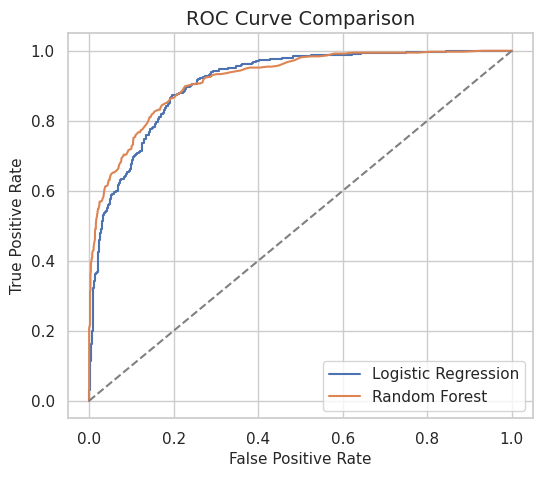

In [ ]:
from sklearn.metrics import roc_curve

log_fpr, log_tpr, _ = roc_curve(y_test, log_probs)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)

plt.figure(figsize=(6,5))
plt.plot(log_fpr, log_tpr, label="Logistic Regression")
plt.plot(rf_fpr, rf_tpr, label="Random Forest")
plt.plot([0,1], [0,1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
# Adjust threshold to improve recall (example: 0.35)

threshold = 0.35

custom_preds = (rf_probs >= threshold).astype(int)

print("Custom Threshold Confusion Matrix:")
print(confusion_matrix(y_test, custom_preds))

print("\nClassification Report:")
print(classification_report(y_test, custom_preds))

Custom Threshold Confusion Matrix:
[[830 114]
 [ 87 287]]

Classification Report:
              precision    recall  f1-score   support

           0       0.91      0.88      0.89       944
           1       0.72      0.77      0.74       374

    accuracy                           0.85      1318
   macro avg       0.81      0.82      0.82      1318
weighted avg       0.85      0.85      0.85      1318



### Threshold Adjustment

Lowering the classification threshold increases recall, allowing the model to identify more high-risk customers.

This may be appropriate in a retention context where missing a churner is more costly than contacting a customer who would have stayed.

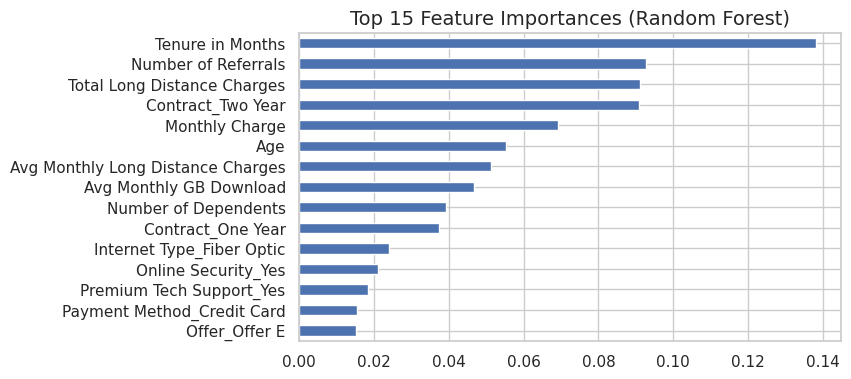

In [ ]:
importances = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(15)

importances.plot(kind="barh")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()
plt.show()

### Feature Importance

Tenure, contract type, internet type, and monthly charges emerge as primary drivers of churn, aligning with patterns observed during EDA.

This consistency between exploratory analysis and model output increases confidence in the findings.

## Model Comparison Summary

- Both Logistic Regression and Random Forest outperform the baseline model.
- Random Forest achieves stronger ROC-AUC and better recall performance.
- Churn risk is primarily driven by tenure, contract type, internet service type, and pricing factors.
- Threshold adjustment allows alignment of model performance with business priorities.

The Random Forest model is selected as the final model due to superior predictive performance and flexibility.

# 5. Business Insights & Recommendations

This section translates model findings into actionable retention strategies designed to reduce customer churn and protect recurring revenue.

## Executive Summary

The analysis identifies customer tenure, contract type, internet service type, pricing, and payment method as primary drivers of churn.

Customers on month-to-month contracts with Fiber internet service represent the highest-risk segment, particularly when combined with non-automated payment methods.

The final Random Forest model demonstrates strong predictive performance and can be used to proactively identify high-risk customers for targeted retention outreach.

## Key Drivers of Churn

1. **Short Tenure**
   - Customers early in their lifecycle are significantly more likely to churn.
   - Early engagement and onboarding experience are critical.

2. **Month-to-Month Contracts**
   - Lack of long-term commitment strongly increases churn risk.
   - Contract incentives may reduce volatility.

3. **Fiber Internet Service**
   - Fiber customers exhibit elevated churn rates.
   - May reflect pricing sensitivity or higher service expectations.

4. **Higher Monthly Charges**
   - Price appears positively associated with churn.
   - Value perception may influence retention.

5. **Manual Payment Methods**
   - Customers paying via mailed check or non-automated methods show higher churn.
   - Automated billing may improve retention stability.

## Priority Retention Segments

The highest-risk segment consists of:

- Month-to-month contract holders  
- Fiber internet subscribers  
- Bank withdrawal payment users  

This group exhibits churn rates exceeding 60% and represents a substantial customer base.

These customers should be prioritized for proactive outreach.

## Recommended Retention Actions

1. **Early Lifecycle Engagement**
   - Implement structured onboarding within the first 3–6 months.
   - Offer proactive support for new customers.

2. **Contract Conversion Incentives**
   - Provide discounts or perks for upgrading from month-to-month to annual plans.

3. **Fiber Customer Experience Audit**
   - Evaluate service reliability and pricing competitiveness in Fiber segments.

4. **Promotional Optimization**
   - Analyze effectiveness of Offer A and B.
   - Reassess Offer E targeting strategy.

5. **Encourage Automated Payments**
   - Provide small incentives for credit card or auto-pay enrollment.

## Model Deployment Strategy

The classification threshold can be adjusted depending on business priorities:

- Lower threshold → Higher recall (capture more churners)
- Higher threshold → Higher precision (reduce unnecessary outreach)

If the cost of losing a customer exceeds the cost of outreach, a lower threshold is recommended to maximize churn detection.

## Potential Business Impact

If the model identifies high-risk customers with 70% recall, and retention outreach reduces churn by even 10–15% within that segment, the company could preserve significant recurring revenue.

Even modest improvements in churn reduction can materially increase customer lifetime value and profitability.

## Limitations and Next Steps

- The dataset represents a single point-in-time snapshot (Q2 2022).
- Causal relationships cannot be confirmed without experimental testing.
- Future improvements could include:
  - Time-series behavioral data
  - Customer support interaction metrics
  - A/B testing of retention interventions

## Final Conclusion

This project demonstrates that customer churn can be predicted with strong performance using behavioral, contract, and service-level features.

By integrating predictive modeling with targeted retention strategies, the company can proactively reduce churn and improve long-term customer value.